In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns",None)
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("german_credit_data.csv")

In [5]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [10]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [11]:
df.shape

(1000, 11)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [15]:
df.describe(include='all').transpose().round(2).T

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.0,1000.0,1000,1000.0,1000,817,606,1000.0,1000.0,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.5,35.546,NaN,1.904,NaN,NaN,NaN,3271.258,20.903,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.0,19.0,NaN,0.0,NaN,NaN,NaN,250.0,4.0,NaN,NaN
25%,249.75,27.0,NaN,2.0,NaN,NaN,NaN,1365.5,12.0,NaN,NaN
50%,499.5,33.0,NaN,2.0,NaN,NaN,NaN,2319.5,18.0,NaN,NaN
75%,749.25,42.0,NaN,2.0,NaN,NaN,NaN,3972.25,24.0,NaN,NaN


In [16]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [20]:
df = df.dropna().reset_index(drop=True)

In [21]:
df.isnull().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [24]:
df.shape

(522, 11)

In [25]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [26]:
df.drop(columns = "Unnamed: 0", inplace = True)

In [27]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

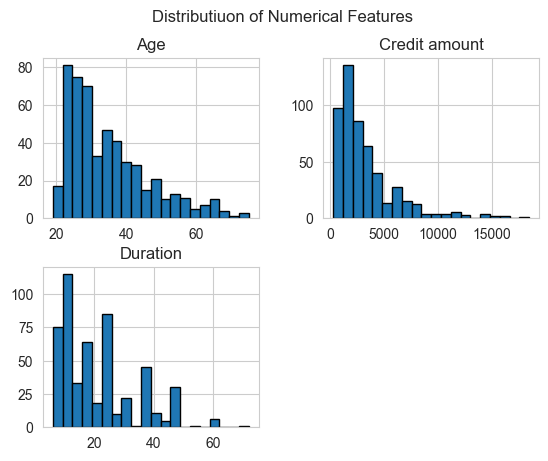

In [36]:
df[["Age","Credit amount","Duration"]].hist(bins=20, edgecolor="black")
plt.suptitle("Distributiuon of Numerical Features")
plt.show()

In [37]:
df[["Age","Credit amount","Duration"]].skew().round(2)

Age              1.12
Credit amount    2.06
Duration         1.06
dtype: float64

In [38]:
df[["Age","Credit amount","Duration"]].kurt().round(2)

Age              0.68
Credit amount    4.95
Duration         0.66
dtype: float64

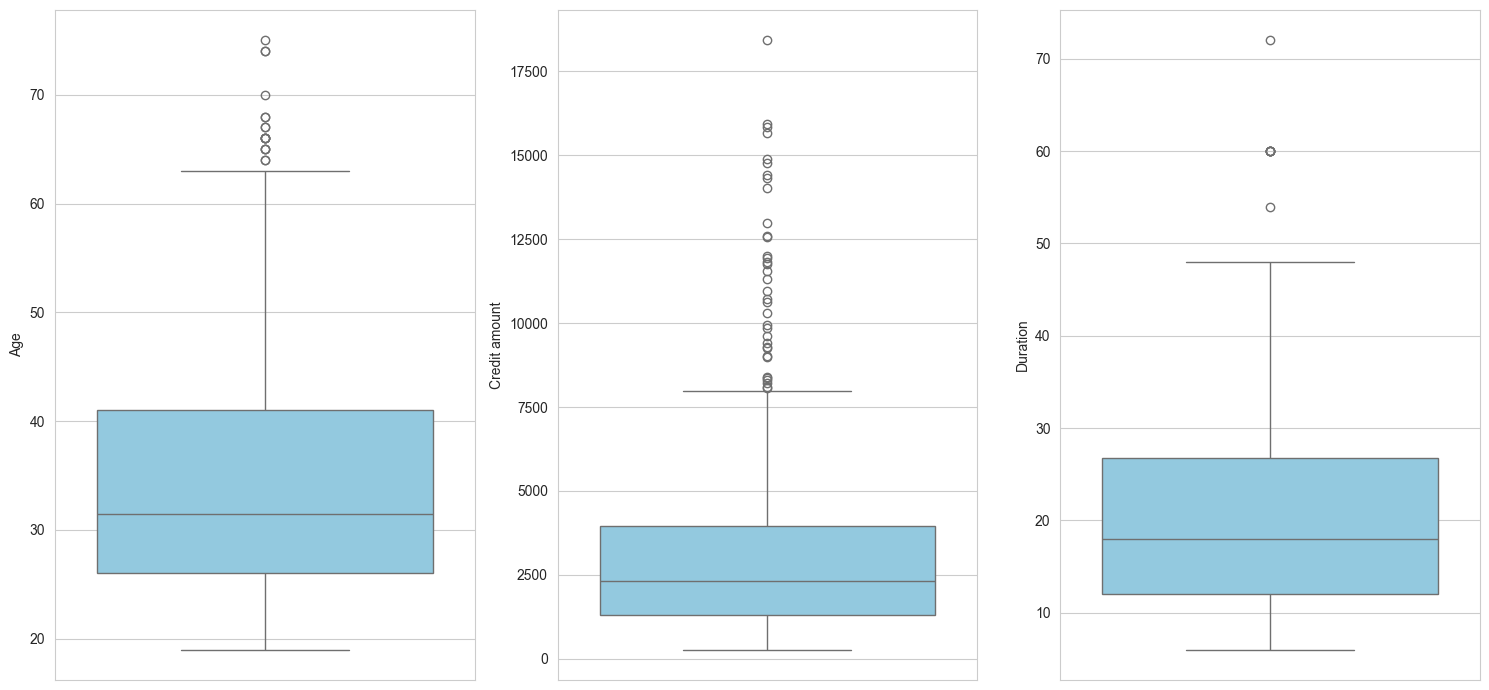

In [46]:
plt.figure(figsize=(15,7))
for i, col in enumerate (["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col],color='skyblue')

plt.tight_layout()
plt.show()

In [47]:
categorical_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

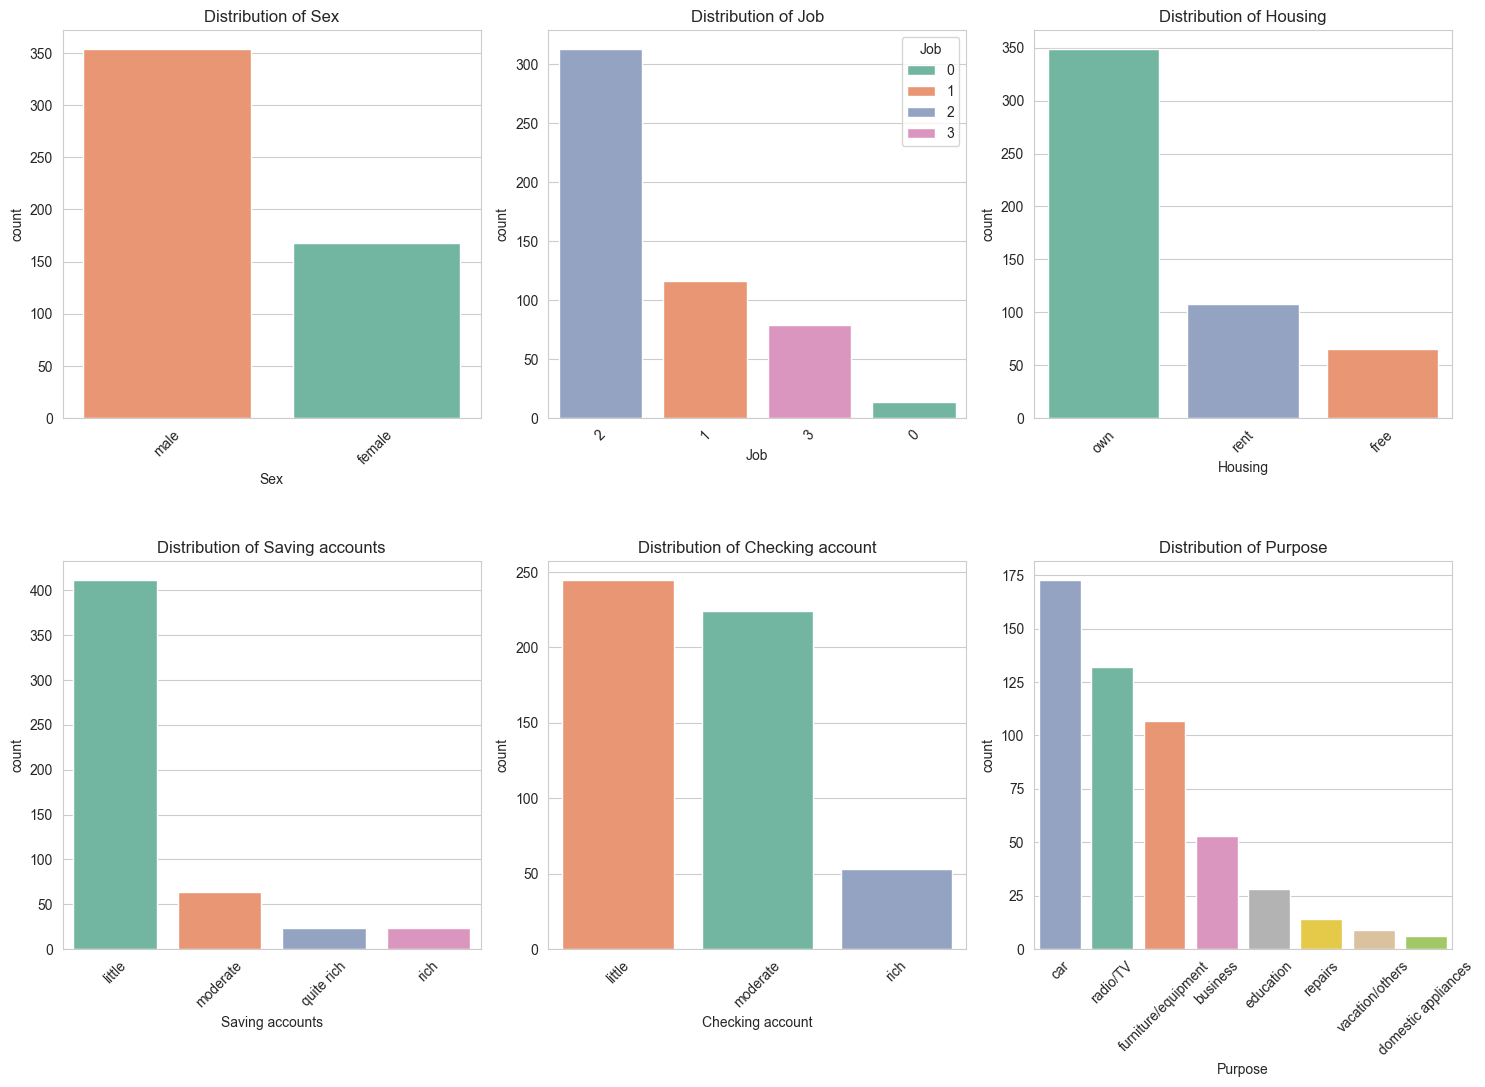

In [53]:
plt.figure(figsize=(15,15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, 
                  x=col,
                  hue=col,
                  palette='Set2',
                  order = df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [54]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [56]:
corr = df[['Age','Job','Credit amount', 'Duration']].corr().round(2)
corr

,Age,Job,Credit amount,Duration
Age,1.00,0.04,0.08,0.00
Job,0.04,1.00,0.33,0.20
Credit amount,0.08,0.33,1.00,0.61
Duration,0.00,0.20,0.61,1.00
